# Day 16 — MACD 指标（⭐重点）

**目标**：理解MACD不是新东西，而是EMA思想的叠加应用

- 🌅 上午：MACD三要素原理
- ☀️ 下午：手算MACD + 标准双面板图
- 🌙 晚上：3只股票MACD信号实战

In [1]:
# ===== 基础设置 =====
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
from matplotlib.gridspec import GridSpec

font_manager.fontManager.addfont('/System/Library/Fonts/Hiragino Sans GB.ttc')
plt.rcParams['font.family'] = 'Hiragino Sans GB'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 环境就绪')

✅ 环境就绪


## 🌅 上午：MACD是什么？

### 一句话

> **MACD = 两根EMA的差，再对差做一次EMA。** 三层嵌套，但每一层都是你Day 15学过的。

### 三要素

```
EMA(12) ──┐
           ├── 差值 → DIF 线（快线）
EMA(26) ──┘

DIF ──→ EMA(9) → DEA 线（慢线，信号线）

MACD柱 = DIF - DEA  （柱状图，红涨绿跌）
```

### 物理直觉

| 概念 | 直觉 |
|------|------|
| **DIF** | 短期和长期谁跑得快。DIF>0 = 短期在上（涨势），DIF<0 = 短期在下（跌势）|
| **DEA** | DIF自己的移动平均，DIF的「平滑版」|
| **MACD柱** | DIF和DEA之间的距离。柱子变高 = 加速，柱子变矮 = 减速 |

### 金叉/死叉

- **金叉**：DIF 从下方向上穿过 DEA → 买入信号
- **死叉**：DIF 从上方向下穿过 DEA → 卖出信号
- **零轴穿越**：DIF 从下穿过0 → 趋势转多；从上穿过0 → 趋势转空

> 💡 MACD的金叉死叉本质上和Day15的MA金叉死叉是一回事——都是「快线穿慢线」。只是这里的快线是DIF，慢线是DEA。

In [2]:
# 加载茅台数据
df = pd.read_csv('../data/茅台.csv')
df['日期'] = pd.to_datetime(df['日期'])
df = df.set_index('日期').sort_index()

print(f'数据: {len(df)} 行, {df.index[0].date()} ~ {df.index[-1].date()}')

数据: 250 行, 2025-07-01 ~ 2026-07-10


## ☀️ 下午：手算MACD

### 计算步骤

1. EMA(12) = 收盘价的12日指数移动平均
2. EMA(26) = 收盘价的26日指数移动平均
3. DIF = EMA(12) - EMA(26)
4. DEA = DIF的9日EMA
5. MACD柱 = (DIF - DEA) × 2  （惯例×2放大，让柱子看得清楚）

In [3]:
# ===== 手算MACD全过程 =====

# 第1步：EMA(12) 和 EMA(26)
df['EMA12'] = df['收盘'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['收盘'].ewm(span=26, adjust=False).mean()

# 第2步：DIF = 快线 - 慢线
df['DIF'] = df['EMA12'] - df['EMA26']

# 第3步：DEA = DIF的9日EMA（信号线）
df['DEA'] = df['DIF'].ewm(span=9, adjust=False).mean()

# 第4步：MACD柱 = (DIF - DEA) × 2
df['MACD柱'] = (df['DIF'] - df['DEA']) * 2

# 验证：看最近10天的计算过程
print('MACD计算过程（最近10天）：')
df[['收盘', 'EMA12', 'EMA26', 'DIF', 'DEA', 'MACD柱']].tail(10).round(2)

MACD计算过程（最近10天）：


,收盘,EMA12,EMA26,DIF,DEA,MACD柱
日期,,,,,,
2026-06-29,1194.96,1205.08,1235.80,-30.72,-29.42,-2.59
2026-06-30,1185.49,1202.06,1232.07,-30.01,-29.54,-0.93
2026-07-01,1193.01,1200.67,1229.18,-28.51,-29.33,1.65
2026-07-02,1203.00,1201.03,1227.24,-26.21,-28.71,5.00
2026-07-03,1194.45,1200.02,1224.81,-24.79,-27.93,6.27
2026-07-06,1206.91,1201.08,1223.49,-22.41,-26.82,8.83
2026-07-07,1188.80,1199.19,1220.92,-21.73,-25.80,8.15
2026-07-08,1199.30,1199.21,1219.32,-20.11,-24.66,9.11
2026-07-09,1182.19,1196.59,1216.57,-19.98,-23.73,7.50


In [4]:
# ===== 验证：手算 vs Pandas直接算 =====

# 用最后一天的数据手算一遍
close = df['收盘']
n = len(close)

# EMA手算逻辑：EMA_today = P_today × k + EMA_yesterday × (1-k)
# k_12 = 2/(12+1), k_26 = 2/(26+1)
k12 = 2 / 13
k26 = 2 / 27

# 从第一个有效值开始递推
def hand_ema(series, span):
    """手写EMA，和Pandas ewm(span, adjust=False)对比"""
    k = 2 / (span + 1)
    ema = [series.iloc[0]]  # 第1天 EMA = 第1天价格
    for i in range(1, len(series)):
        ema.append(series.iloc[i] * k + ema[-1] * (1 - k))
    return pd.Series(ema, index=series.index)

hand_ema12 = hand_ema(close, 12)
hand_ema26 = hand_ema(close, 26)
hand_dif = hand_ema12 - hand_ema26
k9 = 2 / 10
hand_dea = hand_ema(hand_dif, 9)
hand_bar = (hand_dif - hand_dea) * 2

print('最后一天对比：')
print(f'  手算 EMA12: {hand_ema12.iloc[-1]:.2f}  |  Pandas EMA12: {df["EMA12"].iloc[-1]:.2f}')
print(f'  手算 EMA26: {hand_ema26.iloc[-1]:.2f}  |  Pandas EMA26: {df["EMA26"].iloc[-1]:.2f}')
print(f'  手算 DIF:   {hand_dif.iloc[-1]:.2f}  |  Pandas DIF:   {df["DIF"].iloc[-1]:.2f}')
print(f'  手算 DEA:   {hand_dea.iloc[-1]:.2f}  |  Pandas DEA:   {df["DEA"].iloc[-1]:.2f}')
print(f'  手算 MACD柱: {hand_bar.iloc[-1]:.2f}  |  Pandas MACD柱: {df["MACD柱"].iloc[-1]:.2f}')
print('\n→ 手算和 Pandas 一致！MACD 就是用 EMA 套出来的。')

最后一天对比：
  手算 EMA12: 1197.88  |  Pandas EMA12: 1197.88
  手算 EMA26: 1215.71  |  Pandas EMA26: 1215.71
  手算 DIF:   -17.83  |  Pandas DIF:   -17.83
  手算 DEA:   -22.55  |  Pandas DEA:   -22.55
  手算 MACD柱: 9.44  |  Pandas MACD柱: 9.44

→ 手算和 Pandas 一致！MACD 就是用 EMA 套出来的。


### 标准MACD双面板图

这是所有股票软件（同花顺/东方财富/TradingView）的标准画法：
- 上板：价格 + EMA12/EMA26
- 下板：DIF线 + DEA线 + MACD红绿柱

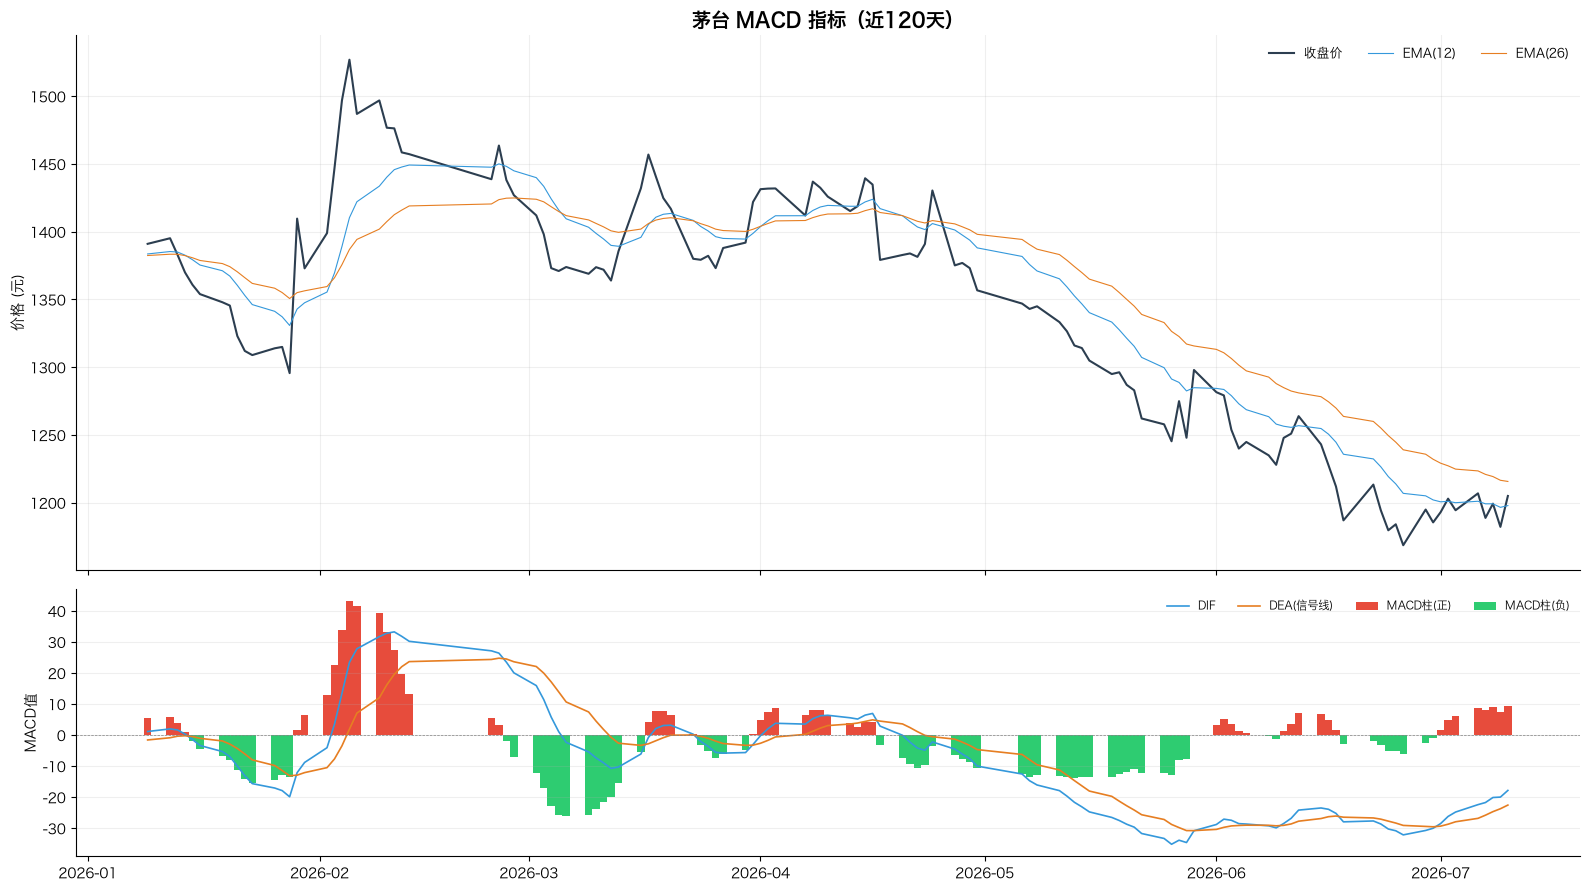

看图的三个要点：
1. 红柱变长 = 短期加速远离长期 → 涨势加速
2. 红柱变短（但仍为正）= 涨势减速 → 可能转势
3. DIF 从上方靠近 DEA → 准备死叉


In [6]:
# ===== 标准MACD双面板图 =====

d = df.iloc[-120:]  # 近120个交易日

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9),
                                gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# ── 上板：价格 + EMA12/EMA26 ──
ax1.plot(d.index, d['收盘'], color='#2c3e50', lw=1.5, label='收盘价')
ax1.plot(d.index, d['EMA12'], color='#3498db', lw=0.8, label='EMA(12)')
ax1.plot(d.index, d['EMA26'], color='#e67e22', lw=0.8, label='EMA(26)')
ax1.set_ylabel('价格 (元)')
ax1.set_title('茅台 MACD 指标（近120天）', fontsize=14, fontweight='bold')
ax1.legend(ncol=3, frameon=False, fontsize=9)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
ax1.grid(True, alpha=0.2)

# ── 下板：MACD（DIF + DEA + 红绿柱）──
# 红柱：DIF > DEA（MACD柱 > 0）
pos = d['MACD柱'] > 0
neg = d['MACD柱'] <= 0
ax2.bar(d.index[pos], d['MACD柱'][pos], color='#e74c3c', width=1.0, label='MACD柱(正)')
ax2.bar(d.index[neg], d['MACD柱'][neg], color='#2ecc71', width=1.0, label='MACD柱(负)')
ax2.plot(d.index, d['DIF'], color='#3498db', lw=1.2, label='DIF')
ax2.plot(d.index, d['DEA'], color='#e67e22', lw=1.2, label='DEA(信号线)')
ax2.axhline(0, color='gray', lw=0.5, ls='--')  # 零轴
ax2.set_ylabel('MACD值')
ax2.legend(ncol=4, frameon=False, fontsize=8)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax2.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

print('看图的三个要点：')
print('1. 红柱变长 = 短期加速远离长期 → 涨势加速')
print('2. 红柱变短（但仍为正）= 涨势减速 → 可能转势')
print('3. DIF 从上方靠近 DEA → 准备死叉')

### MACD金叉/死叉信号检测

In [7]:
# ===== MACD金叉/死叉检测 =====

# 金叉：DIF从下方向上穿过DEA
df['MACD金叉'] = (df['DIF'] > df['DEA']) & (df['DIF'].shift(1) <= df['DEA'].shift(1))

# 死叉：DIF从上方向下穿过DEA
df['MACD死叉'] = (df['DIF'] < df['DEA']) & (df['DIF'].shift(1) >= df['DEA'].shift(1))

# DIF零轴穿越
df['零轴上穿'] = (df['DIF'] > 0) & (df['DIF'].shift(1) <= 0)
df['零轴下穿'] = (df['DIF'] < 0) & (df['DIF'].shift(1) >= 0)

golden = df[df['MACD金叉']]
death = df[df['MACD死叉']]

print(f'近一年 MACD金叉 {len(golden)} 次，MACD死叉 {len(death)} 次')
print(f'零轴上穿 {df["零轴上穿"].sum()} 次，零轴下穿 {df["零轴下穿"].sum()} 次')
print(f'\n金叉日期: {[str(d.date()) for d in golden.index]}')

近一年 MACD金叉 13 次，MACD死叉 12 次
零轴上穿 7 次，零轴下穿 7 次

金叉日期: ['2025-07-02', '2025-07-18', '2025-08-20', '2025-10-16', '2025-11-10', '2025-12-17', '2026-01-05', '2026-01-29', '2026-03-17', '2026-03-31', '2026-06-01', '2026-06-10', '2026-07-01']


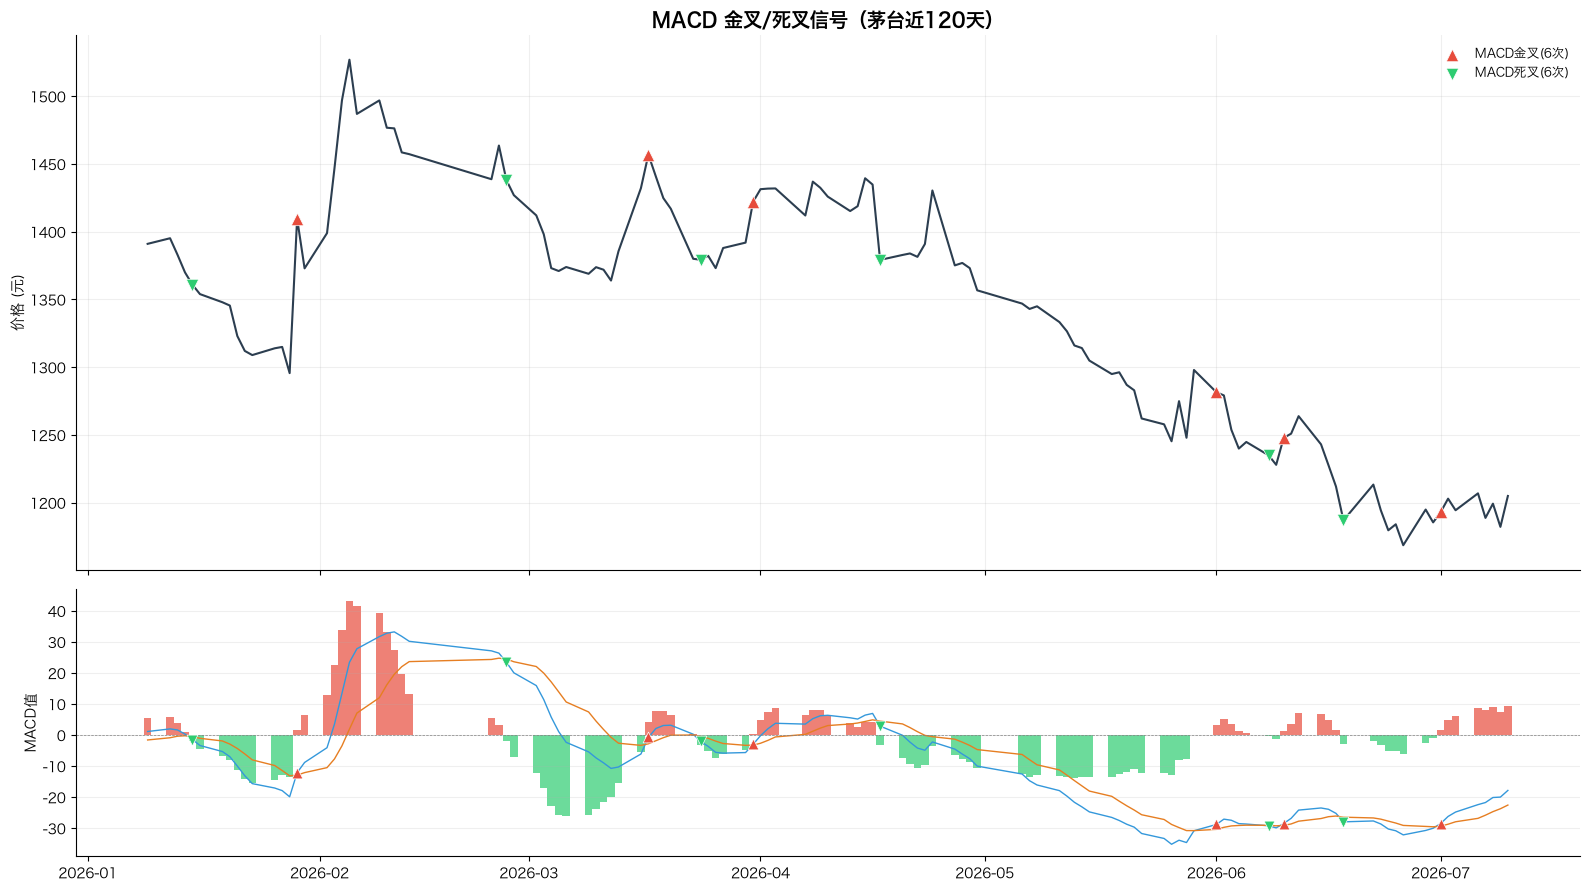

In [8]:
# ===== 画图：MACD金叉/死叉标记在图上 =====

d = df.iloc[-120:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9),
                                gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# 上板
ax1.plot(d.index, d['收盘'], color='#2c3e50', lw=1.5)

# 标金叉
g = d[d['MACD金叉']]
ax1.scatter(g.index, g['收盘'], color='#e74c3c', s=80, zorder=5,
            marker='^', edgecolor='white', lw=0.5, label=f'MACD金叉({len(g)}次)')
# 标死叉
de = d[d['MACD死叉']]
ax1.scatter(de.index, de['收盘'], color='#2ecc71', s=80, zorder=5,
            marker='v', edgecolor='white', lw=0.5, label=f'MACD死叉({len(de)}次)')

ax1.set_ylabel('价格 (元)')
ax1.set_title('MACD 金叉/死叉信号（茅台近120天）', fontsize=14, fontweight='bold')
ax1.legend(frameon=False, fontsize=9)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
ax1.grid(True, alpha=0.2)

# 下板：MACD + 标记
pos, neg = d['MACD柱'] > 0, d['MACD柱'] <= 0
ax2.bar(d.index[pos], d['MACD柱'][pos], color='#e74c3c', width=1.0, alpha=0.7)
ax2.bar(d.index[neg], d['MACD柱'][neg], color='#2ecc71', width=1.0, alpha=0.7)
ax2.plot(d.index, d['DIF'], color='#3498db', lw=1.0)
ax2.plot(d.index, d['DEA'], color='#e67e22', lw=1.0)
ax2.axhline(0, color='gray', lw=0.5, ls='--')

# 在MACD面板也标金叉死叉
ax2.scatter(g.index, g['DIF'], color='#e74c3c', s=60, zorder=5, marker='^', edgecolor='white', lw=0.5)
ax2.scatter(de.index, de['DIF'], color='#2ecc71', s=60, zorder=5, marker='v', edgecolor='white', lw=0.5)

ax2.set_ylabel('MACD值')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax2.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

### MACD信号回测

用Day15同样的方法：信号日买入 → 持有N天 → 统计胜率

In [9]:
# ===== MACD信号回测 =====

def backtest_signal(df, signal_col, hold_days=5):
    """信号出现当天收盘买入，持有hold_days天后卖出"""
    signal_dates = df[df[signal_col]].index
    results = []
    for date in signal_dates:
        pos = df.index.get_loc(date)
        if pos + hold_days >= len(df):
            continue
        buy_price = df['收盘'].iloc[pos]
        sell_price = df['收盘'].iloc[pos + hold_days]
        ret = (sell_price / buy_price - 1) * 100
        results.append({
            '信号日': date.strftime('%Y-%m-%d'),
            f'{hold_days}日后收益率(%)': round(ret, 2)
        })
    return pd.DataFrame(results)

# MACD金叉回测
print('='*50)
print('MACD金叉 后持有5天：')
print('='*50)
gr = backtest_signal(df, 'MACD金叉', hold_days=5)
if len(gr) > 0:
    print(gr.to_string(index=False))
    win = (gr['5日后收益率(%)'] > 0).sum()
    print(f'\n胜率: {win}/{len(gr)} = {win/len(gr)*100:.0f}% | 平均收益: {gr["5日后收益率(%)"].mean():.2f}%')

print()
print('='*50)
print('MACD死叉 后持有5天：')
print('='*50)
dr = backtest_signal(df, 'MACD死叉', hold_days=5)
if len(dr) > 0:
    print(dr.to_string(index=False))
    down = (dr['5日后收益率(%)'] < 0).sum()
    print(f'\n下跌概率: {down}/{len(dr)} = {down/len(dr)*100:.0f}% | 平均收益: {dr["5日后收益率(%)"].mean():.2f}%')

MACD金叉 后持有5天：
       信号日  5日后收益率(%)
2025-07-02       0.68
2025-07-18       1.30
2025-08-20      -0.14
2025-10-16      -1.18
2025-11-10       0.62
2025-12-17      -0.60
2026-01-05      -0.20
2026-01-29       8.32
2026-03-17      -5.33
2026-03-31       1.06
2026-06-01      -3.64
2026-06-10      -2.88
2026-07-01       0.53

胜率: 6/13 = 46% | 平均收益: -0.11%

MACD死叉 后持有5天：
       信号日  5日后收益率(%)
2025-07-17       5.51
2025-07-31       0.05
2025-09-17      -3.54
2025-10-28      -1.15
2025-11-26      -1.44
2025-12-31       3.11
2026-01-15      -3.59
2026-02-26      -4.67
2026-03-24       3.09
2026-04-17       3.72
2026-06-08       0.66
2026-06-18      -1.55

下跌概率: 6/12 = 50% | 平均收益: 0.02%


findfont: Failed to find font weight bold, now using 600.


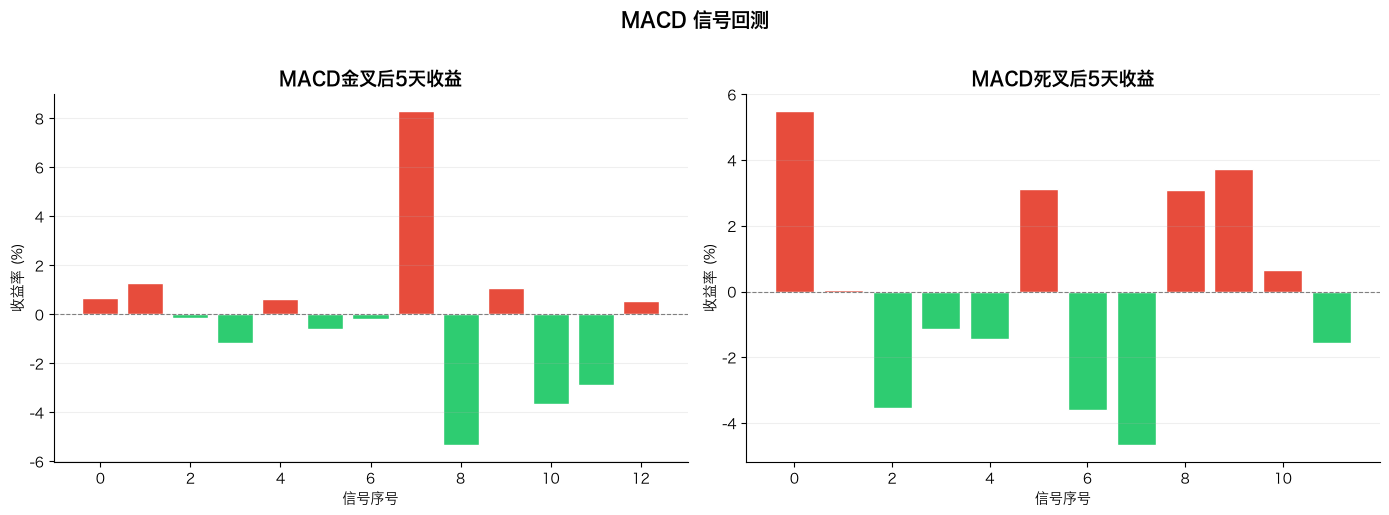

In [10]:
# ===== 可视化回测结果 =====

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if len(gr) > 0:
    colors = ['#e74c3c' if r > 0 else '#2ecc71' for r in gr['5日后收益率(%)']]
    ax1.bar(range(len(gr)), gr['5日后收益率(%)'], color=colors, edgecolor='white')
    ax1.axhline(0, color='gray', lw=0.8, ls='--')
    ax1.set_title('MACD金叉后5天收益', fontsize=13, fontweight='bold')
    ax1.set_ylabel('收益率 (%)')
    ax1.set_xlabel('信号序号')

if len(dr) > 0:
    colors = ['#2ecc71' if r < 0 else '#e74c3c' for r in dr['5日后收益率(%)']]
    ax2.bar(range(len(dr)), dr['5日后收益率(%)'], color=colors, edgecolor='white')
    ax2.axhline(0, color='gray', lw=0.8, ls='--')
    ax2.set_title('MACD死叉后5天收益', fontsize=13, fontweight='bold')
    ax2.set_ylabel('收益率 (%)')
    ax2.set_xlabel('信号序号')

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('MACD 信号回测', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🌙 晚上：3只股票MACD信号实战

用你手头的其他3只股票，各找MACD金叉/死叉信号，记录信号日后1个月的走势。

findfont: Failed to find font weight bold, now using 600.


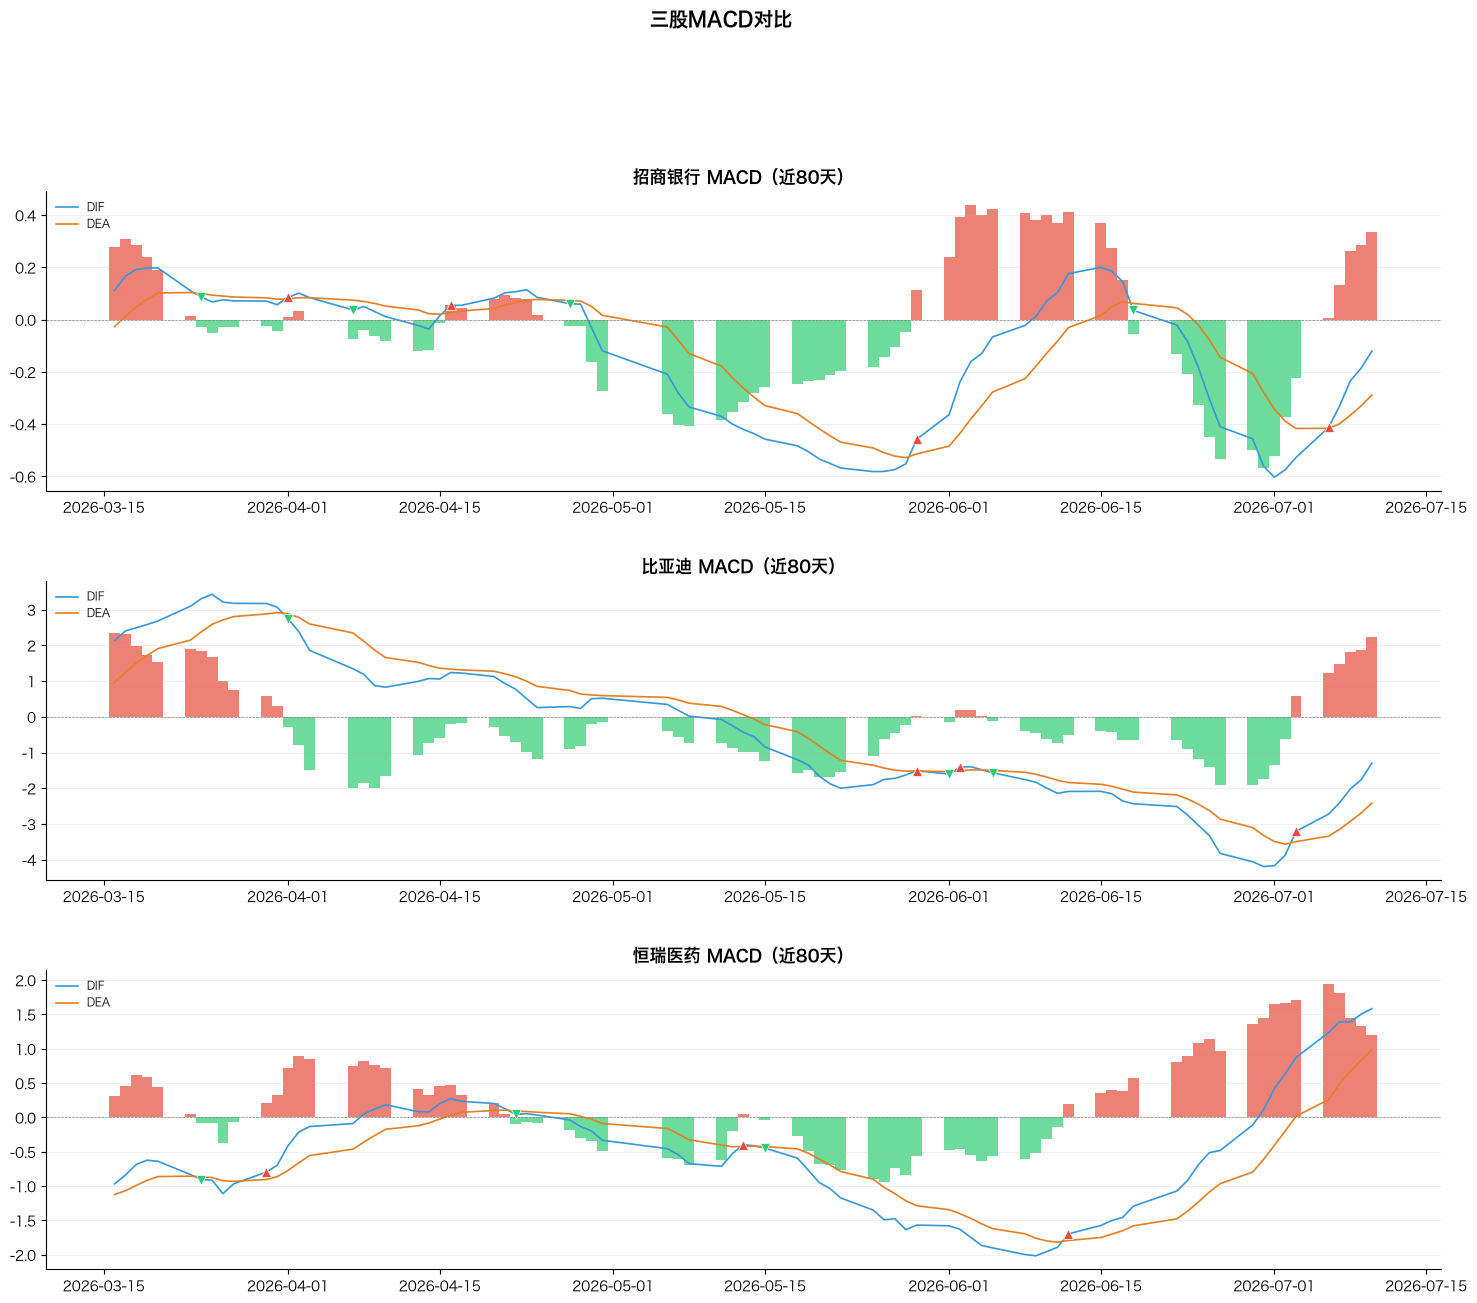

In [11]:
# ===== 多股MACD分析 =====

stocks = {
    '招商银行': '../data/招商银行.csv',
    '比亚迪': '../data/比亚迪.csv',
    '恒瑞医药': '../data/恒瑞医药.csv',
}

def calc_macd(df):
    """给一个DataFrame加上MACD相关列"""
    df = df.copy()
    df['EMA12'] = df['收盘'].ewm(span=12, adjust=False).mean()
    df['EMA26'] = df['收盘'].ewm(span=26, adjust=False).mean()
    df['DIF'] = df['EMA12'] - df['EMA26']
    df['DEA'] = df['DIF'].ewm(span=9, adjust=False).mean()
    df['MACD柱'] = (df['DIF'] - df['DEA']) * 2
    df['MACD金叉'] = (df['DIF'] > df['DEA']) & (df['DIF'].shift(1) <= df['DEA'].shift(1))
    df['MACD死叉'] = (df['DIF'] < df['DEA']) & (df['DIF'].shift(1) >= df['DEA'].shift(1))
    return df

# 画三股对比图
fig = plt.figure(figsize=(18, 14))
gs = GridSpec(3, 1, figure=fig, hspace=0.3)

for idx, (name, path) in enumerate(stocks.items()):
    s = pd.read_csv(path)
    s['日期'] = pd.to_datetime(s['日期'])
    s = s.set_index('日期').sort_index()
    s = calc_macd(s)
    d = s.iloc[-80:]  # 近80天
    
    ax = fig.add_subplot(gs[idx])
    # 红绿柱
    pos, neg = d['MACD柱'] > 0, d['MACD柱'] <= 0
    ax.bar(d.index[pos], d['MACD柱'][pos], color='#e74c3c', width=1.0, alpha=0.7)
    ax.bar(d.index[neg], d['MACD柱'][neg], color='#2ecc71', width=1.0, alpha=0.7)
    ax.plot(d.index, d['DIF'], color='#3498db', lw=1.2, label='DIF')
    ax.plot(d.index, d['DEA'], color='#e67e22', lw=1.2, label='DEA')
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    
    # 标信号
    g = d[d['MACD金叉']]
    de = d[d['MACD死叉']]
    ax.scatter(g.index, g['DIF'], color='#e74c3c', s=50, zorder=5, marker='^', edgecolor='white', lw=0.5)
    ax.scatter(de.index, de['DIF'], color='#2ecc71', s=50, zorder=5, marker='v', edgecolor='white', lw=0.5)
    
    ax.set_title(f'{name} MACD（近80天）', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', frameon=False, fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('三股MACD对比', fontsize=14, fontweight='bold', y=1.01)
plt.show()

In [12]:
# ===== 统计每只股的信号 =====

for name, path in stocks.items():
    s = pd.read_csv(path)
    s['日期'] = pd.to_datetime(s['日期'])
    s = s.set_index('日期').sort_index()
    s = calc_macd(s)
    
    golden = s[s['MACD金叉']]
    death = s[s['MACD死叉']]
    
    print(f'\n{"="*50}')
    print(f'📊 {name}')
    print(f'{"="*50}')
    print(f'MACD金叉 {len(golden)} 次: {[str(d.date()) for d in golden.index]}')
    print(f'MACD死叉 {len(death)} 次: {[str(d.date()) for d in death.index]}')
    
    # 最近一次金叉后的走势
    if len(golden) > 0:
        last_golden_date = golden.index[-1]
        pos = s.index.get_loc(last_golden_date)
        end = min(pos + 21, len(s) - 1)  # 往后看21个交易日≈1个月
        period = s.iloc[pos:end+1]
        change = (period['收盘'].iloc[-1] / period['收盘'].iloc[0] - 1) * 100
        print(f'最近金叉 {last_golden_date.date()} 到 {period.index[-1].date()} 涨跌幅: {change:.2f}%')


📊 招商银行
MACD金叉 11 次: ['2025-07-02', '2025-08-06', '2025-09-10', '2025-10-14', '2025-12-02', '2025-12-30', '2026-01-30', '2026-04-01', '2026-04-16', '2026-05-29', '2026-07-06']
MACD死叉 10 次: ['2025-07-17', '2025-08-11', '2025-09-16', '2025-11-28', '2025-12-03', '2026-01-09', '2026-03-24', '2026-04-07', '2026-04-27', '2026-06-18']
最近金叉 2026-07-06 到 2026-07-10 涨跌幅: 0.41%

📊 比亚迪
MACD金叉 11 次: ['2025-07-03', '2025-07-18', '2025-08-18', '2025-09-17', '2025-09-29', '2025-11-14', '2025-11-28', '2026-02-11', '2026-05-29', '2026-06-02', '2026-07-03']
MACD死叉 11 次: ['2025-07-02', '2025-07-07', '2025-07-31', '2025-09-04', '2025-09-23', '2025-10-13', '2025-11-18', '2026-01-14', '2026-04-01', '2026-06-01', '2026-06-05']
最近金叉 2026-07-03 到 2026-07-10 涨跌幅: 1.73%

📊 恒瑞医药
MACD金叉 13 次: ['2025-07-04', '2025-07-28', '2025-08-22', '2025-09-01', '2025-11-13', '2025-11-26', '2025-12-23', '2026-01-05', '2026-02-10', '2026-03-10', '2026-03-30', '2026-05-13', '2026-06-12']
MACD死叉 13 次: ['2025-07-02', '2025-07-25', '

## 📝 MACD vs MA 金叉对比

| | MA金叉(5穿20) | MACD金叉(DIF穿DEA) |
|------|:--:|:--:|
| 信号本质 | 短期价格均线穿长期价格均线 | 短期EMA差穿长期EMA差的均线 |
| 反应速度 | 较慢（用原始价格） | 较快（用EMA差，二阶导） |
| 噪音 | 多 | 少（EMA滤了两次） |
| 零轴信息 | 无 | 有（DIF>0=多头，DIF<0=空头） |
| 柱状图 | 无 | 有（看动能加速/减速） |

### 核心认知

> **MACD 没有发明新东西，它只是 MA 思想的迭代应用。** EMA(12)和EMA(26)是你会的，DIF是两者之差，DEA是DIF的EMA——你还是会的。弄懂这个，你就不会被「高大上」的指标名词唬住。

### 信号仍然滞后

金叉出现时，价格已经涨了一段。和Day15的金叉一样，这个信号描述的是"已经发生的事"。

### MACD柱的独特价值

柱子变短（无论正负）= 动能减弱 = 趋势可能反转。这个信息MA给不了。

> 💡 **顶背离**（价格新高，MACD柱不新高）和**底背离**（价格新低，MACD柱不新低）是MACD最有价值的用法——Day 18会深入讲。

## 📝 今天的发现

运行完上面的代码后，回答这三个问题（写进 `day16/学习笔记.txt`）：

1. MACD的三要素分别是什么？每个是怎么算出来的？
2. MACD金叉和MA金叉有什么本质区别？哪个信号出现得更早？
3. 3只股票中，谁的MACD信号最频繁？信号后1个月的走势和信号方向一致吗？